# 02 — Rasterize

Rasterize **all 52 Latin letters** from downloaded TTF fonts into binary 256×256 images and compute **all N² pair distances** as ground truth for kerning estimation.
Target = advance + kern_adjustment + centroid_diff. Kern=0 for pairs without explicit GPOS kerning.

**Input**: `fonts_catalog.csv`, `kerning_pairs.csv` (lookup), `data/raw/fonts/*.ttf`
**Output**: `data/processed/glyphs/*.npz` (now with N² pair_distances), `manifest.csv`


In [1]:
import logging
from pathlib import Path

import freetype
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from fontTools.ttLib import TTFont

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "fonts"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
GLYPH_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 256
BASELINE_Y = 160
MIN_PX = 8
MAX_PX = 320
LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
LATIN_52_SET = set(LATIN_52)
LATIN_52_IDX = {g: i for i, g in enumerate(LATIN_52)}

FT_LOAD = freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_NORMAL

In [2]:
cat = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
kp = pd.read_csv(DATA_PROCESSED / "kerning_pairs.csv")
log.info("Catalog: %d rows (%d ok)", len(cat), (cat["status"] == "ok").sum())
log.info("Pairs: %d rows", len(kp))

cat_ok = cat[cat["status"] == "ok"].reset_index(drop=True)
pairs_grouped = kp.groupby("font_stem")

2026-07-24 02:46:54,130 | INFO | Catalog: 7284 rows (7284 ok)
2026-07-24 02:46:54,131 | INFO | Pairs: 715826 rows


In [3]:
def _glyph_bitmap(face, char):
    face.load_char(char, FT_LOAD)
    slot = face.glyph
    bmp = slot.bitmap
    return bmp, slot.bitmap_left, slot.bitmap_top, slot.advance.x / 64.0

def render_centered(face, char):
    face.load_char(char, FT_LOAD)
    slot = face.glyph
    bmp = slot.bitmap
    if bmp.width == 0 or bmp.rows == 0:
        return None, None
    arr = np.array(bmp.buffer, dtype=np.uint8).reshape(bmp.rows, bmp.width)
    arr = (arr > 0).astype(np.uint8)
    x_left = (IMAGE_SIZE - bmp.width) // 2
    y_top = BASELINE_Y - slot.bitmap_top
    if x_left < 0 or y_top < 0 or (x_left + bmp.width) > IMAGE_SIZE or (y_top + bmp.rows) > IMAGE_SIZE:
        return None, None
    canvas = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    canvas[y_top:y_top + bmp.rows, x_left:x_left + bmp.width] = arr
    ys, xs = np.where(canvas > 0)
    return canvas, (float(xs.mean()), float(ys.mean())) if len(xs) > 0 else (None, None)

def centroid_rel(face, char):
    face.load_char(char, FT_LOAD)
    slot = face.glyph
    bmp = slot.bitmap
    if bmp.width == 0 or bmp.rows == 0:
        return None, slot.advance.x / 64.0
    arr = np.array(bmp.buffer, dtype=np.uint8).reshape(bmp.rows, bmp.width)
    arr = (arr > 0).astype(np.uint8)
    pen_x = 256
    temp = np.zeros((512, 1024), dtype=np.uint8)
    x_left = int(pen_x + slot.bitmap_left)
    y_top = int(BASELINE_Y - slot.bitmap_top)
    if x_left < 0 or y_top < 0 or (x_left + bmp.width) > 1024 or (y_top + bmp.rows) > 512:
        return None, slot.advance.x / 64.0
    temp[y_top:y_top + bmp.rows, x_left:x_left + bmp.width] = arr
    ys, xs = np.where(temp > 0)
    return float(xs.mean() - pen_x), slot.advance.x / 64.0 if len(xs) > 0 else (None, slot.advance.x / 64.0)

def fits_all(face, px_size):
    face.set_pixel_sizes(0, px_size)
    return all(render_centered(face, g)[0] is not None for g in LATIN_52)

def find_shared_size(face):
    lo, hi, best = MIN_PX, MAX_PX, None
    while lo <= hi:
        mid = (lo + hi) // 2
        if fits_all(face, mid):
            best = mid
            lo = mid + 1
        else:
            hi = mid - 1
    return best

In [4]:
manifest = []

for _, row in tqdm(cat_ok.iterrows(), total=len(cat_ok), desc="Rasterizing"):
    stem = row["stem"]
    font_path = DATA_RAW / f"{stem}.ttf"
    if not font_path.exists():
        manifest.append({"stem": stem, "status": "failed", "error": "TTF not found"})
        continue

    stem_pairs = pairs_grouped.get_group(stem) if stem in pairs_grouped.groups else None
    # We no longer skip fonts without kerning pairs — we still rasterize all 52 letters.
    # Fonts with no kerning pairs will have empty pair_* arrays.

    try:
        face = freetype.Face(str(font_path))
        shared = find_shared_size(face)
        if shared is None:
            manifest.append({"stem": stem, "status": "failed", "error": "no valid shared size"})
            continue

        ttfont = TTFont(str(font_path))
        upem_val = ttfont["head"].unitsPerEm
        ttfont.close()

        face.set_pixel_sizes(0, shared)

        
        unique_glyphs = list(LATIN_52)
        idx_map = {}
        images, ccanvas, crel, advs = [], [], [], []
        glyph_names = []

        for g in unique_glyphs:
            img, cc = render_centered(face, g)
            if img is None:
                continue  # glyph not in this font (e.g. uppercase-only)
            rc, av = centroid_rel(face, g)
            if rc is None:
                continue
            idx_map[g] = len(images)
            images.append(img)
            ccanvas.append(cc)
            crel.append(rc)
            advs.append(av)
            glyph_names.append(g)

        if len(images) == 0:
            manifest.append({"stem": stem, "status": "failed", "error": "no renderable glyphs"})
            continue

        n_glyphs = len(images)

        # Compute pair distances for ALL N² pairs
        # Build kern lookup: kerning_pairs.csv has kern≠0 entries only
        # For kern=0: ground truth = centroids distance
        kern_lookup = {}
        if stem_pairs is not None:
            for _, pr in stem_pairs.iterrows():
                kern_lookup[(pr["glyph1"], pr["glyph2"])] = float(pr["kern"])

        M = n_glyphs * n_glyphs
        pair_dists = np.zeros(M, dtype=np.float32)
        pair_left = np.zeros(M, dtype=np.int32)
        pair_right = np.zeros(M, dtype=np.int32)
        kern_vals = np.zeros(M, dtype=np.int32)

        scale = shared / upem_val
        idx = 0
        for li in range(n_glyphs):
            g1 = glyph_names[li]
            for ri in range(n_glyphs):
                g2 = glyph_names[ri]
                kpx = kern_lookup.get((g1, g2), 0.0) * scale
                pdist = advs[li] + kpx + crel[ri] - crel[li]
                pair_dists[idx] = np.float32(pdist)
                pair_left[idx] = np.int32(LATIN_52_IDX[g1])
                pair_right[idx] = np.int32(LATIN_52_IDX[g2])
                kern_vals[idx] = np.int32(int(kern_lookup.get((g1, g2), 0)))
                idx += 1
        np.savez_compressed(
            GLYPH_DIR / f"{stem}.npz",
            glyph_images=np.array(images, dtype=np.uint8),
            glyph_names=np.array(glyph_names),
            glyph_indices=np.array([LATIN_52_IDX[g] for g in glyph_names], dtype=np.int32),
            centroids_canvas=np.array(ccanvas, dtype=np.float32),
            centroids_rel=np.array(crel, dtype=np.float32),
            advances=np.array(advs, dtype=np.float32),
            pair_distances=pair_dists,
            pair_left=pair_left,
            pair_right=pair_right,
            kern_values=kern_vals,
            shared_size=np.int32(shared),
            image_size=np.int32(IMAGE_SIZE),
            baseline_y=np.int32(BASELINE_Y),
        )

        manifest.append({
            "stem": stem, "status": "ok", "glyphs": n_glyphs,
            "pairs": M, "shared_size": shared, "error": None,
        })

    except Exception as e:
        manifest.append({"stem": stem, "status": "failed", "error": str(e)})

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(DATA_PROCESSED / "manifest.csv", index=False)
log.info("OK: %d | Failed: %d", (manifest_df["status"] == "ok").sum(),
         (manifest_df["status"] == "failed").sum())


Rasterizing:   0%|          | 0/7284 [00:00<?, ?it/s]

2026-07-24 04:26:49,384 | WARNING | 'created' timestamp seems very low; regarding as unix timestamp
2026-07-24 04:53:44,379 | INFO | OK: 7263 | Failed: 21


In [5]:
print("=" * 55)
print("SUMMARY")
print("=" * 55)

ok_m = manifest_df[manifest_df["status"] == "ok"]
fail_m = manifest_df[manifest_df["status"] == "failed"]
total_glyphs = ok_m["glyphs"].sum() if "glyphs" in ok_m else 0
total_pairs = ok_m["pairs"].sum() if "pairs" in ok_m else 0

print(f"\n  Variants processed   : {len(ok_m)} ok / {len(fail_m)} failed")
print(f"  Total glyphs saved  : {total_glyphs}")
print(f"  Total pair distances : {total_pairs}  (N² per font)")
if len(ok_m) > 0:
    print(f"  Avg shared_size      : {ok_m['shared_size'].mean():.1f} px")
    n52 = (ok_m["glyphs"] == 52).sum()
    print(f"  Fonts with N=52      : {n52} ({n52/len(ok_m)*100:.1f}%)")
    print(f"  Mean N               : {ok_m['glyphs'].mean():.1f}")
if len(fail_m) > 0:
    print(f"\n  Failure reasons:")
    for err, cnt in fail_m["error"].value_counts().items():
        print(f"    {err}: {cnt}")

print("\n" + "=" * 55)


SUMMARY

  Variants processed   : 7263 ok / 21 failed
  Total glyphs saved  : 377676.0
  Total pair distances : 19639152.0  (N² per font)
  Avg shared_size      : 212.5 px
  Fonts with N=52      : 7263 (100.0%)
  Mean N               : 52.0

  Failure reasons:
    no valid shared size: 16
    FT_Exception:  (raster overflow): 3
    FT_Exception:  (execution context too long): 2



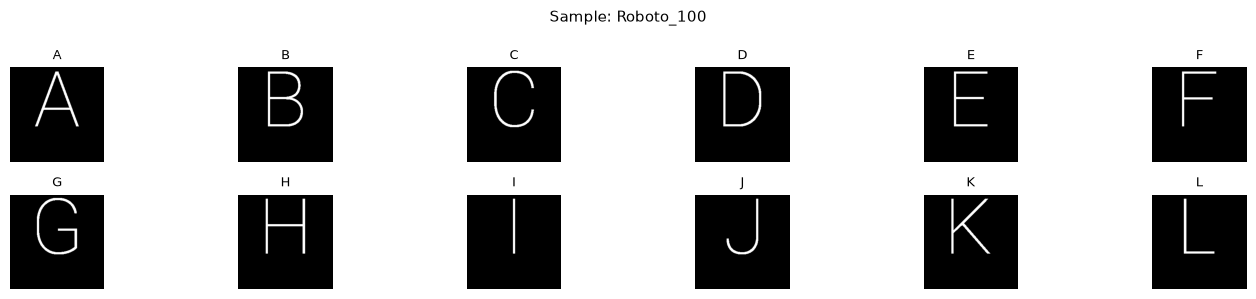

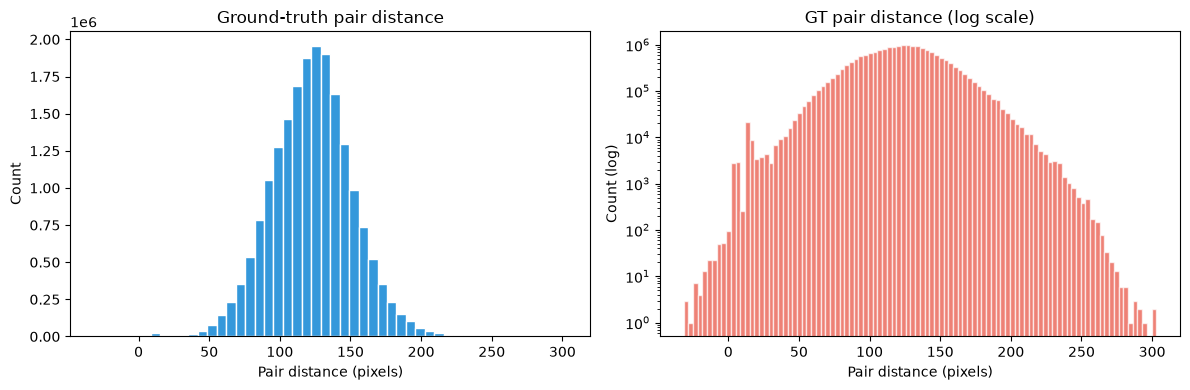

Pair distance: min=-31.7  max=303.0  mean=122.6  median=123.0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(ok_m) > 0:
    sample = np.load(GLYPH_DIR / f"{ok_m.iloc[0]['stem']}.npz")
    imgs = sample["glyph_images"]
    names = sample["glyph_names"]

    n_show = min(12, len(imgs))
    fig, axes = plt.subplots(2, n_show // 2, figsize=(n_show * 1.2, 3))
    for k, ax in enumerate(axes.flatten()):
        if k < n_show:
            ax.imshow(imgs[k], cmap="gray")
            ax.set_title(str(names[k]), fontsize=9)
            ax.axis("off")
    plt.suptitle(f"Sample: {ok_m.iloc[0]['stem']}", fontsize=11)
    plt.tight_layout()
    plt.show()

if total_pairs > 0:
    all_pds = []
    for _, r in ok_m.iterrows():
        z = np.load(GLYPH_DIR / f"{r['stem']}.npz")
        all_pds.append(z["pair_distances"])
    all_pds = np.concatenate(all_pds)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(all_pds, bins=50, color="#3498db", edgecolor="white")
    axes[0].set_xlabel("Pair distance (pixels)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Ground-truth pair distance")

    axes[1].hist(all_pds, bins=100, color="#e74c3c", edgecolor="white", alpha=0.7)
    axes[1].set_xlabel("Pair distance (pixels)")
    axes[1].set_ylabel("Count (log)")
    axes[1].set_yscale("log")
    axes[1].set_title("GT pair distance (log scale)")
    plt.tight_layout()
    plt.show()
    print(f"Pair distance: min={all_pds.min():.1f}  max={all_pds.max():.1f}  mean={all_pds.mean():.1f}  median={np.median(all_pds):.1f}")